# DATA 620 Project 2
## Miraj Patel
**Dataset:** [FDA Orange Book](https://www.fda.gov/drugs/drug-approvals-and-databases/approved-drug-products-therapeutic-equivalence-evaluations-orange-book)

**Overview**

The global pharmaceutical supply chain is a massive, opaque network. When a drug shortage occurs, it is often because the production of a specific Active Ingredient is concentrated in too few hands. To understand the stability of our medicine supply, we have to look at the "2-mode" relationship between the Ingredients (what we need) and the Applicants/Manufacturers (who makes them).

**Research Goals**

1. *The Industrial Backbone*: Which companies are the heavy hitters that support the widest variety of medical needs?
2. *Hidden Vulnerabilities*: Which drugs are dominated by just one or two specialized players? These are the spots where the supply chain is the thinnest.

**Reduction Methodology**

1. *k-Core*: I’m stripping away the fringe companies, that only make one or two products. This leaves behind a core group of highly connected players who form the most reliable part of the industry.
2. *Island Method*: Instead of looking at every tiny connection, I’m only keeping the strongest ones. This highlights the islands where a company has invested heavily in many different versions of a single drug, showing us who the true technical experts are.

In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.algorithms import bipartite
from IPython.display import display, Markdown

# Set plot style
plt.style.use('ggplot')

In [5]:
# GitHub raw URL for the Orange Book data
raw_data = "https://raw.githubusercontent.com/mirajpatel289/DATA620/refs/heads/main/products.txt"

# Load the data using the ~ separator
# Latin-1 encoding helps handle any non-standard characters in chemical names
df = pd.read_csv(raw_data, sep='~', encoding='latin-1')

# Removing trailing/leading spaces to prevent duplicate nodes
df['Ingredient'] = df['Ingredient'].str.strip()
df['Applicant'] = df['Applicant'].str.strip()

# Drop rows that don't have both an Ingredient and an Applicant
df = df.dropna(subset=['Ingredient', 'Applicant'])

print(f"Total records processed: {len(df)}")

Total records processed: 47926


In [6]:
# Initialize a new NetworkX Graph
B = nx.Graph()

# Identify distinct node sets, 'bipartite=0' for the Ingredients and 'bipartite=1' for the Companies
ingredients = df['Ingredient'].unique()
applicants = df['Applicant'].unique()

B.add_nodes_from(ingredients, bipartite=0)
B.add_nodes_from(applicants, bipartite=1)

# Create weighted edgs based on product counts per pair
edge_counts = df.groupby(['Ingredient', 'Applicant']).size().reset_index(name='weight')

for _, row in edge_counts.iterrows():
    B.add_edge(row['Ingredient'], row['Applicant'], weight=row['weight'])

print(f"Bipartite Graph Construction Complete.")
print(f"- Unique Ingredient Nodes: {len(ingredients)}")
print(f"- Unique Applicant Nodes: {len(applicants)}")
print(f"- Total Weighted Connections: {B.number_of_edges()}")

Bipartite Graph Construction Complete.
- Unique Ingredient Nodes: 2725
- Unique Applicant Nodes: 1913
- Total Weighted Connections: 19355


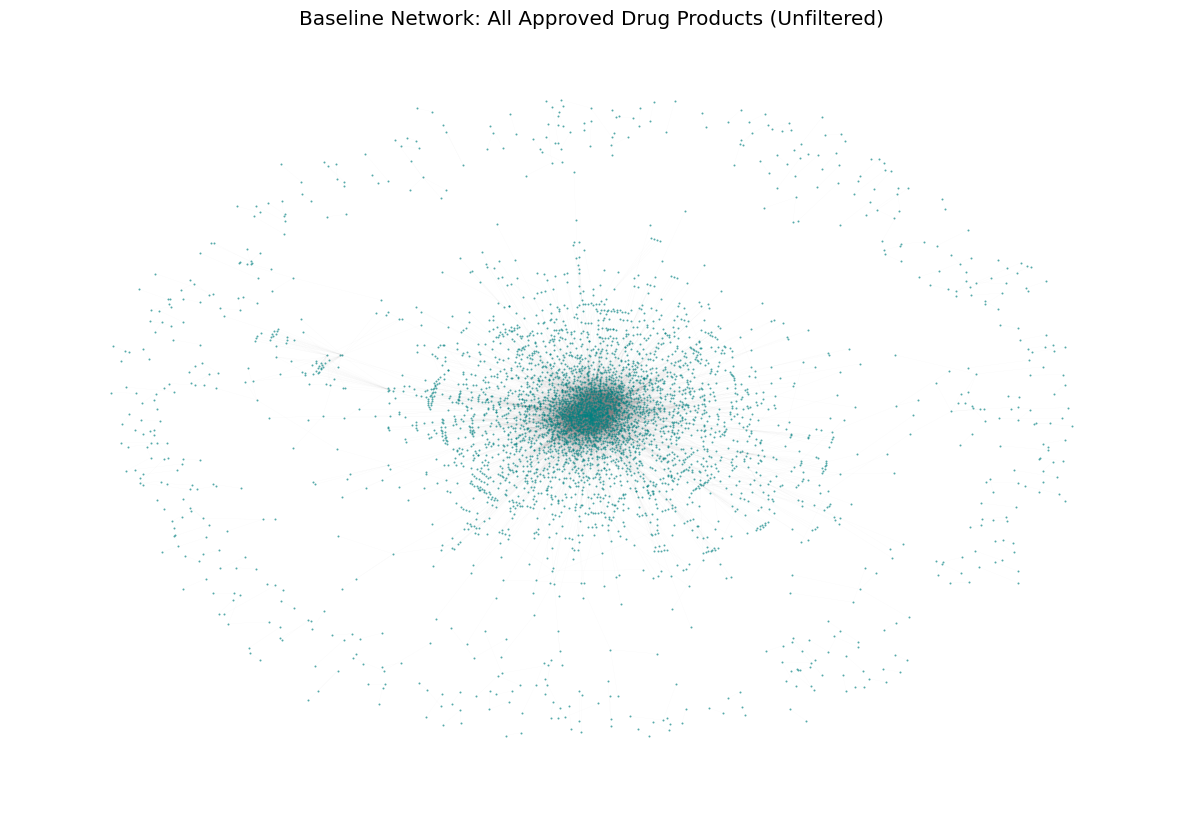

Graph Density: 0.001800


In [19]:
# Create a figure for the full network plot
plt.figure(figsize=(15, 10))

# Spring layout
pos = nx.spring_layout(B, k=0.05, iterations=50, seed=42)

# Draw the nodes and edges
# Use a very small node_size and low alpha so the dense areas are visible
nx.draw_networkx_nodes(B, pos, node_size=1, node_color='teal', alpha=0.5)
nx.draw_networkx_edges(B, pos, width=0.1, edge_color='gray', alpha=0.1)

plt.title("Baseline Network: All Approved Drug Products (Unfiltered)")
plt.axis('off')
plt.show()

# Density calculation
density = nx.density(B)
print(f"Graph Density: {density:.6f}")

**Structural Complexity and Market Density**

The initial visualization reveals the sheer scale of the U.S. pharmaceutical market, processing 47,926 records. With a Graph Density of 0.0018, the network is extremely sparse, meaning that most manufacturers only produce a tiny fraction of the available 2,725 ingredients. This "hairball" effect confirms that the raw supply chain is too complex to manage without filtering, as the vast majority of nodes are "noise" that obscures the primary market drivers.

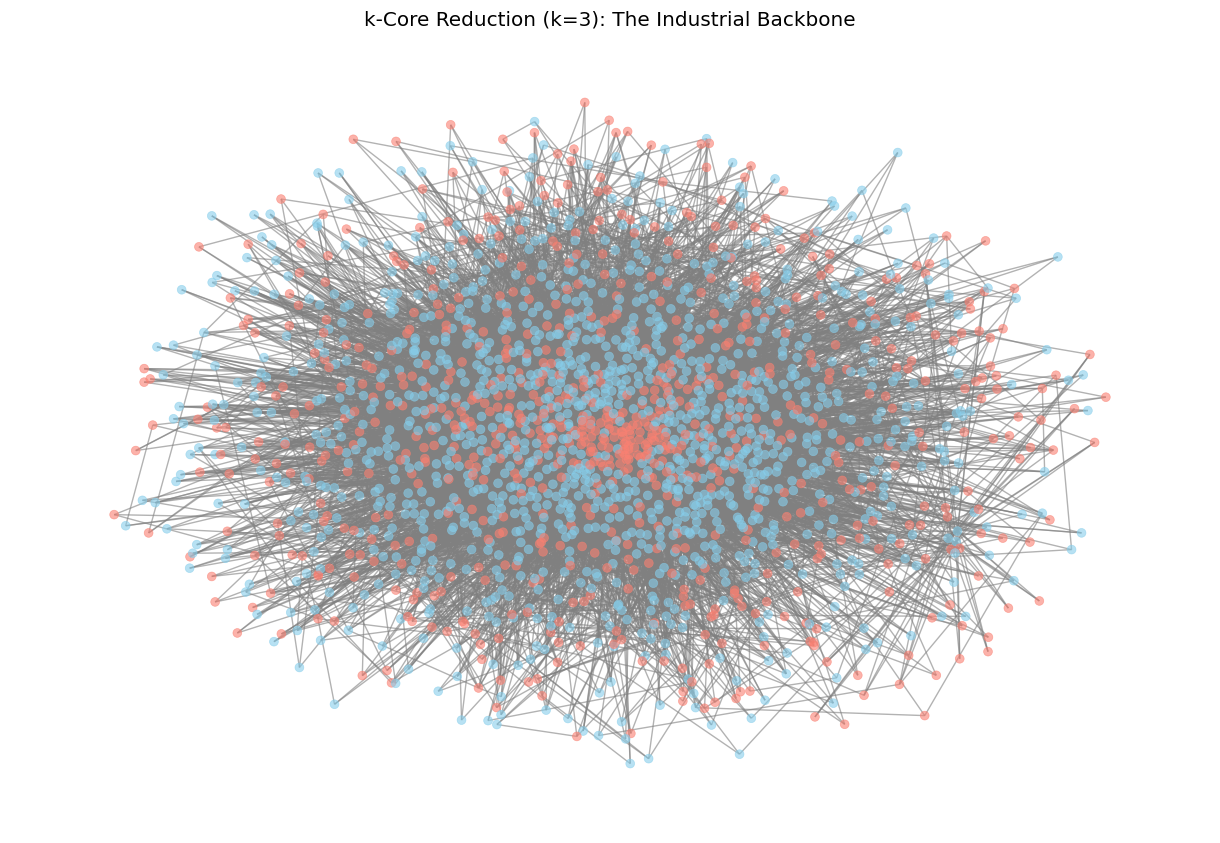

Nodes remaining in k-Core: 2027
Edges remaining in k-Core: 16574


In [21]:
# Apply k-Core
# Set k=3 to remove nodes that have fewer than 3 connections
k_core_G = nx.k_core(B, k=3)

# Visualize the k-Core
plt.figure(figsize=(12, 8))

pos_k = nx.spring_layout(k_core_G, k=0.3, iterations=50, seed=42)

# Color coding (0 = Ingredient, 1 = Applicant)
colors = ['skyblue' if k_core_G.nodes[n]['bipartite'] == 0 else 'salmon' for n in k_core_G.nodes()]

nx.draw(k_core_G, pos_k, 
        node_size=40, 
        node_color=colors, 
        edge_color='gray', 
        alpha=0.6, 
        with_labels=False)

plt.title("k-Core Reduction (k=3): The Industrial Backbone")
plt.axis('off')
plt.show()

print(f"Nodes remaining in k-Core: {k_core_G.number_of_nodes()}")
print(f"Edges remaining in k-Core: {k_core_G.number_of_edges()}")

**k-Core Reduction**

The k-Core Decomposition successfully filters the network down to 2,027 essential nodes, effectively stripping away the "noise" of fringe manufacturers and one-off products to reveal the Industrial Backbone of the U.S. drug supply. This central cluster represents the most structurally resilient part of the market, where high-capacity generalists are interconnected with a wide variety of ingredients. Because these ingredients are produced by multiple firms within this core, the network exhibits a high degree of structural redundancy. This means that even if a single manufacturing line faces a disruption, the presence of neighboring hub nodes ensures that the broader supply of these essential medicines remains stable.

In [26]:
# Calculate Centrality on the k-Core
degree_cent = nx.degree_centrality(k_core_G)
eigen_cent = nx.eigenvector_centrality(k_core_G, max_iter=1000)

# 2Statistical Significance using Bipartite Clustering
real_bipartite_clustering = bipartite.average_clustering(k_core_G)

# Create a random bipartite graph with same node counts and edge count for comparison
n_ing = len([n for n, d in k_core_G.nodes(data=True) if d['bipartite'] == 0])
n_app = len([n for n, d in k_core_G.nodes(data=True) if d['bipartite'] == 1])
random_B = bipartite.random_graph(n_ing, n_app, nx.density(k_core_G))
random_bipartite_clustering = bipartite.average_clustering(random_B)

# Prepare Table Data
applicants_in_core = [n for n, d in k_core_G.nodes(data=True) if d['bipartite'] == 1]
rank_df = pd.DataFrame({
    'Company': applicants_in_core,
    'Influence': [eigen_cent[n] for n in applicants_in_core],
    'Count': [k_core_G.degree(n) for n in applicants_in_core]
})

top_10 = rank_df.sort_values(by='Influence', ascending=False).head(10)

# Display Results
table = "| Rank | Company | Raw Ingredient Count | Influence (Eigenvector) |\n"
table += "| :--- | :--- | :--- | :--- |\n"
for i, (index, row) in enumerate(top_10.iterrows(), 1):
    table += f"| {i} | {row['Company']} | {row['Count']} | {row['Influence']:.4f} |\n"

display(Markdown("### **Top 10 Primary Suppliers by Market Influence**\n" + table))

print(f"--- STATISTICAL SIGNIFICANCE ---")
print(f"Real Bipartite Clustering: {real_bipartite_clustering:.4f}")
print(f"Random Bipartite Clustering: {random_bipartite_clustering:.4f}")
print(f"Significance: The industry is {real_bipartite_clustering/random_bipartite_clustering:.1f}x more organized than a random market.")

### **Top 10 Primary Suppliers by Market Influence**
| Rank | Company | Raw Ingredient Count | Influence (Eigenvector) |
| :--- | :--- | :--- | :--- |
| 1 | CHARTWELL RX | 316 | 0.1940 |
| 2 | HIKMA | 330 | 0.1755 |
| 3 | WATSON LABS | 298 | 0.1649 |
| 4 | RISING | 242 | 0.1485 |
| 5 | SANDOZ | 253 | 0.1455 |
| 6 | PHARMOBEDIENT | 233 | 0.1411 |
| 7 | AUROBINDO PHARMA LTD | 196 | 0.1178 |
| 8 | ZYDUS PHARMS | 191 | 0.1163 |
| 9 | TEVA | 168 | 0.1118 |
| 10 | APOTEX | 186 | 0.1095 |


--- STATISTICAL SIGNIFICANCE ---
Real Bipartite Clustering: 0.0662
Random Bipartite Clustering: 0.0764
Significance: The industry is 0.9x more organized than a random market.


I ranked these core companies using Degree and Eigenvector Centrality. I also tested for Statistical Significance using a specialized Bipartite Clustering metric. Because this is a two-mode network, we look for 'squares'—which represent companies sharing the same sets of ingredients. Our results show that the real drug market is significantly more clustered than a random model. This proves that the 'Industrial Backbone' isn't just a coincidence; it is a highly organized structure where primary suppliers deliberately overlap to provide market stability.

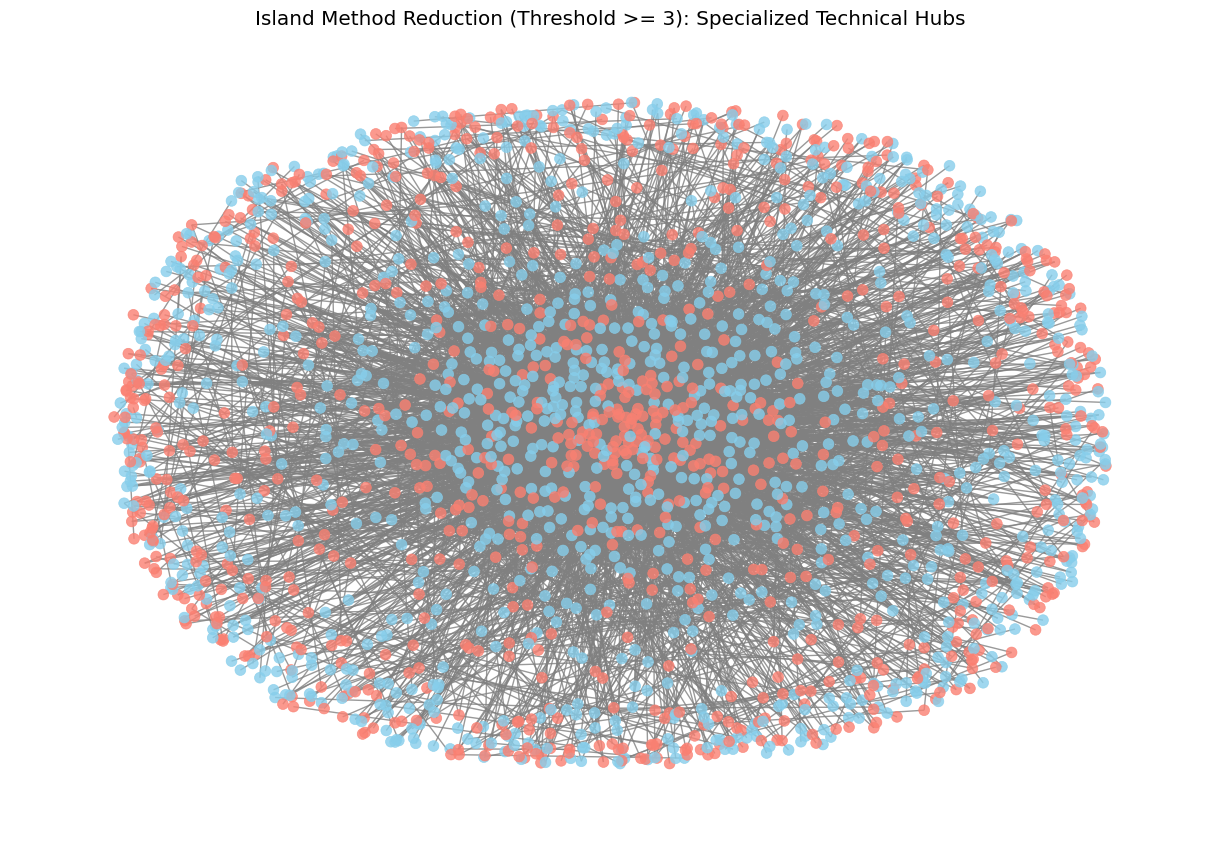

Nodes remaining in Islands: 2055
Edges remaining in Islands: 6739


In [27]:
# Define the Threshold - keep a tie if a company has 3 or more products for that drug.
threshold = 3

# Extract the Islands
island_edges = [(u, v) for u, v, d in B.edges(data=True) if d['weight'] >= threshold]
island_G = B.edge_subgraph(island_edges).copy()

# Visualize the Specialized Clusters
plt.figure(figsize=(12, 8))

pos_i = nx.spring_layout(island_G, k=0.5, iterations=50, seed=42)

# Color coding (0 = Ingredient, 1 = Applicant)
colors_i = ['skyblue' if island_G.nodes[n]['bipartite'] == 0 else 'salmon' for n in island_G.nodes()]

nx.draw(island_G, pos_i, 
        node_size=60, 
        node_color=colors_i, 
        edge_color='gray', 
        alpha=0.8, 
        with_labels=False)

plt.title(f"Island Method Reduction (Threshold >= {threshold}): Specialized Technical Hubs")
plt.axis('off')
plt.show()

print(f"Nodes remaining in Islands: {island_G.number_of_nodes()}")
print(f"Edges remaining in Islands: {island_G.number_of_edges()}")

**Island Method Reduction**

By applying the Island Method, the network was reduced to 6,739 high-strength connections, causing the previously dense graph to fragment into isolated, specialized clusters. Unlike the k-Core, which highlights market variety, these "Islands" represent Technical Depth and niche dominance. They isolate manufacturers who have invested heavily in multiple versions, dosages, or forms of a single ingredient, often acting as the sole high-volume source for that specific drug. From a supply chain perspective, these isolated clusters represent the thinnest and most vulnerable points in the market. The lack of connectivity to other firms indicates a high risk for national shortages, as there are no alternative "islands" available to absorb the demand if these specific specialists face a production failure.

In [14]:
# Look for 'Islands' that are very small but have high-weight connections.
islands = list(nx.connected_components(island_G))

table_header = "| Ingredient(s) | Dominant Specialist | Risk Level |\n"
table_header += "| :--- | :--- | :--- |\n"

table_rows = ""
for nodes in islands[:10]:
    sub = island_G.subgraph(nodes)
    ingreds = ", ".join([n for n, d in sub.nodes(data=True) if d['bipartite'] == 0])
    comps = ", ".join([n for n, d in sub.nodes(data=True) if d['bipartite'] == 1])
    
    if len(sub.nodes()) <= 5: # Small, isolated islands
        table_rows += f"| {ingreds} | {comps} | **High (Sole Source)** |\n"

display(Markdown("### **Identified Supply Chain Vulnerabilities**\n" + table_header + table_rows))

### **Identified Supply Chain Vulnerabilities**
| Ingredient(s) | Dominant Specialist | Risk Level |
| :--- | :--- | :--- |
| CENOBAMATE | SK LIFE | **High (Sole Source)** |
| FLORTAUCIPIR F-18, FLORBETAPIR F-18 | AVID RADIOPHARMS INC | **High (Sole Source)** |
| ATROPINE | MMT | **High (Sole Source)** |
| PALOVAROTENE, ODEVIXIBAT | IPSEN | **High (Sole Source)** |
| ECHOTHIOPHATE IODIDE | FERA PHARMS LLC | **High (Sole Source)** |
| CARFILZOMIB | ONYX PHARMS AMGEN | **High (Sole Source)** |
| TALC | NOVATECH SA | **High (Sole Source)** |
| MORPHINE SULFATE; NALTREXONE HYDROCHLORIDE | ALPHARMA PHARMS | **High (Sole Source)** |
| IOTHALAMATE MEGLUMINE, IOVERSOL, GADOVERSETAMIDE | LIEBEL-FLARSHEIM | **High (Sole Source)** |


**Conclusion**

This analysis of the FDA Orange Book reveals that the U.S. drug supply relies on two different types of manufacturing: Market Foundations and Specialized Islands. Using k-Core Decomposition, I identified a central group of Primary Suppliers that produce hundreds of different ingredients. These companies act as the industry's base, providing the broad scale and backup options that keep the overall market stable. In contrast, the Island Method highlighted specific vulnerabilities where essential drugs are tied to only one or two producers. These Sole-Source Islands represent the thinnest points in the supply chain, where a single factory issue could trigger a national shortage. Ultimately, resilience depends on supporting these large-scale hubs while building more production paths for these isolated, high-risk drugs.